# Unstable harmonic oscillator

This is an explicit phase-amplitude equation. Has two nonlinear switches. Only one of them seems to work. The final plot has a return map of the new "phase switch". No variation to the dominant frequency yet. I.e. the omega is large unaffected. W is on the phase equation: what impact does it make? How can that impact be improved?

The W variable is added to the phase which means it adds up to the omage - but its values are small and thus the frequency variation is small. Making the coupling constant bigger blocks the simulation, not sure why. But that would be needed to get wider frequency ranges. 

We start with the 2-variable subsystem. It is an unstable harmonic oscillator, see @fig-unstable_harmonic .

The equation is given by:

$$\begin{aligned} \frac{dR}{dt} &= a R \sin^2\theta \\ \frac{d\theta}{dt} &= \omega + \frac{a}{2}\sin(2\theta)\end{aligned}$$



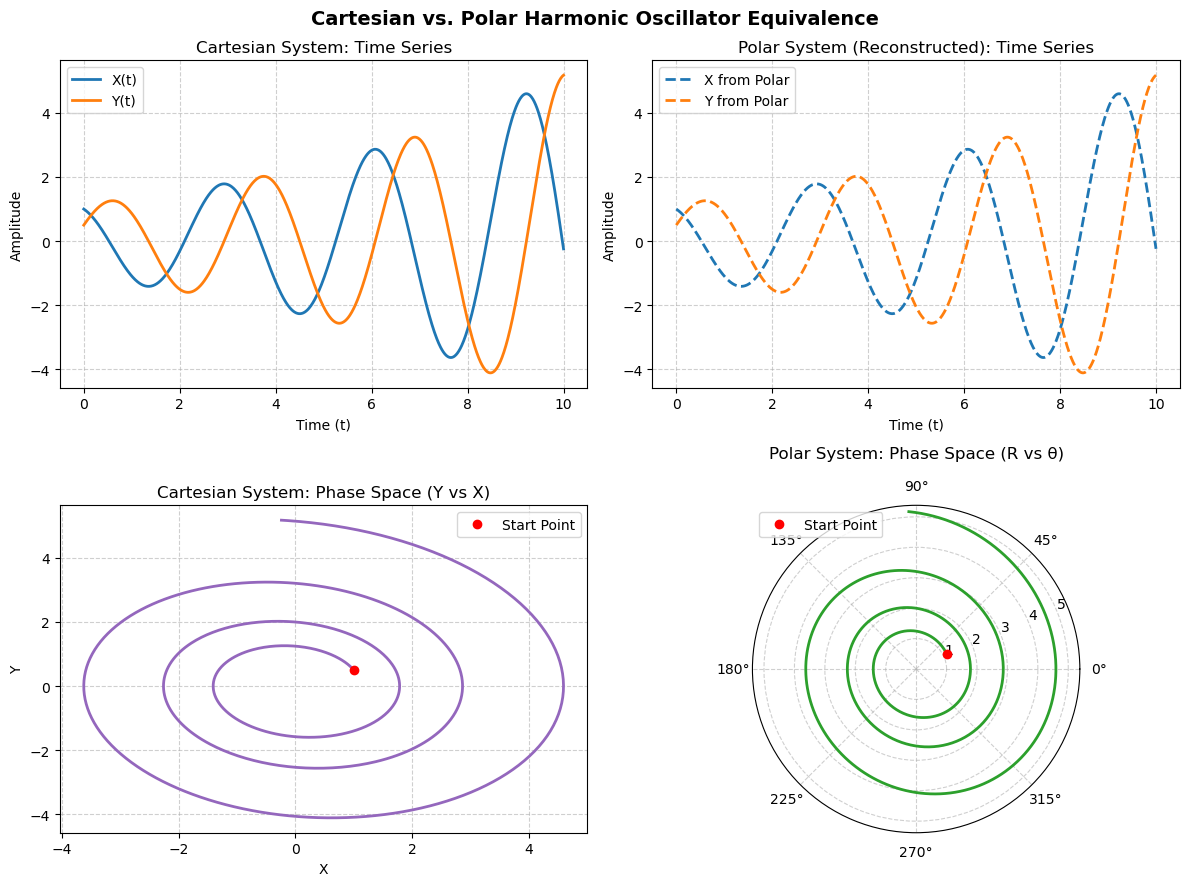

In [3]:
#| label: fig-unstable_harmonic
#| fig-cap: "Expanding harmonic oscillator"

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters
omega = 2.0  # Frequency
a = 0.3      # Instability growth rate (a > 0)

# Initial conditions in Cartesian space
X0 = 1.0
Y0 = 0.5

# Convert initial conditions to Polar space
R0 = np.sqrt(X0**2 + Y0**2)
theta0 = np.arctan2(Y0, X0)

# Time span for simulation
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# --- 1. Define Systems ---

def cartesian_system(t, state, omega, a):
    X, Y = state
    dXdt = -omega * Y
    dYdt = omega * X + a * Y
    return [dXdt, dYdt]

def polar_system(t, state, omega, a):
    R, theta = state
    dRdt = a * R * (np.sin(theta)**2)
    dthetadt = omega + (a / 2.0) * np.sin(2 * theta)
    return [dRdt, dthetadt]

# --- 2. Solve ODEs ---

# Solve Cartesian
sol_cart = solve_ivp(
    cartesian_system, 
    t_span, 
    [X0, Y0], 
    args=(omega, a), 
    t_eval=t_eval, 
    rtol=1e-8, 
    atol=1e-10
)

# Solve Polar
sol_polar = solve_ivp(
    polar_system, 
    t_span, 
    [R0, theta0], 
    args=(omega, a), 
    t_eval=t_eval, 
    rtol=1e-8, 
    atol=1e-10
)

# Convert Polar solution back to Cartesian for direct comparison
R_sol = sol_polar.y[0]
theta_sol = sol_polar.y[1]
X_from_polar = R_sol * np.cos(theta_sol)
Y_from_polar = R_sol * np.sin(theta_sol)

# --- 3. Plot Results ---

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Cartesian vs. Polar Harmonic Oscillator Equivalence", fontsize=14, fontweight="bold")

# Plot 1: Cartesian Time Series (X(t), Y(t))
axes[0, 0].plot(sol_cart.t, sol_cart.y[0], label="X(t)", color="tab:blue", lw=2)
axes[0, 0].plot(sol_cart.t, sol_cart.y[1], label="Y(t)", color="tab:orange", lw=2)
axes[0, 0].set_title("Cartesian System: Time Series")
axes[0, 0].set_xlabel("Time (t)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, linestyle="--", alpha=0.6)
axes[0, 0].legend()

# Plot 2: Polar System Converted to Cartesian Time Series
axes[0, 1].plot(sol_polar.t, X_from_polar, label="X from Polar", color="tab:blue", linestyle="--", lw=2)
axes[0, 1].plot(sol_polar.t, Y_from_polar, label="Y from Polar", color="tab:orange", linestyle="--", lw=2)
axes[0, 1].set_title("Polar System (Reconstructed): Time Series")
axes[0, 1].set_xlabel("Time (t)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True, linestyle="--", alpha=0.6)
axes[0, 1].legend()

# Plot 3: Cartesian Phase Space (Y vs X)
axes[1, 0].plot(sol_cart.y[0], sol_cart.y[1], color="tab:purple", lw=2)
axes[1, 0].plot(X0, Y0, "ro", label="Start Point")
axes[1, 0].set_title("Cartesian System: Phase Space (Y vs X)")
axes[1, 0].set_xlabel("X")
axes[1, 0].set_ylabel("Y")
axes[1, 0].grid(True, linestyle="--", alpha=0.6)
axes[1, 0].legend()

# Plot 4: Polar Phase Space (Polar Coordinates Plot)
ax_polar = fig.add_subplot(2, 2, 4, projection="polar")
axes[1, 1].remove()  # Replace standard axis with polar axis
ax_polar.plot(theta_sol, R_sol, color="tab:green", lw=2)
ax_polar.plot(theta0, R0, "ro", label="Start Point")
ax_polar.set_title("Polar System: Phase Space (R vs θ)", pad=15)
ax_polar.grid(True, linestyle="--", alpha=0.6)
ax_polar.legend(loc="upper left")

plt.tight_layout()
plt.show()

$$X = R \cos\theta, \quad Y = R \sin\theta$$

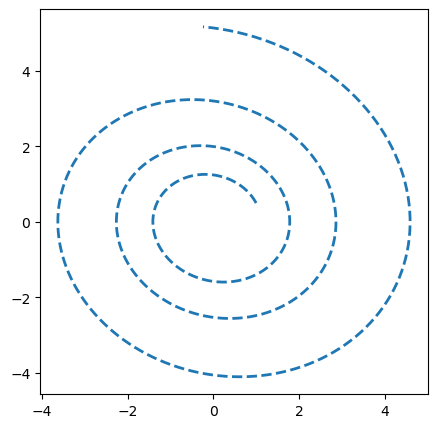

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(X_from_polar, Y_from_polar, label="X from Polar", color="tab:blue", linestyle="--", lw=2);


# The Roessler Equation

$$\begin{aligned} \frac{dR}{dt} &= a R \sin^2\theta - Z \cos\theta \\ \frac{d\theta}{dt} &= \omega + \frac{a}{2}\sin(2\theta) + \frac{Z}{R}\sin\theta \\ \frac{dZ}{dt} &= b + Z(R \cos\theta - c) \end{aligned}$$

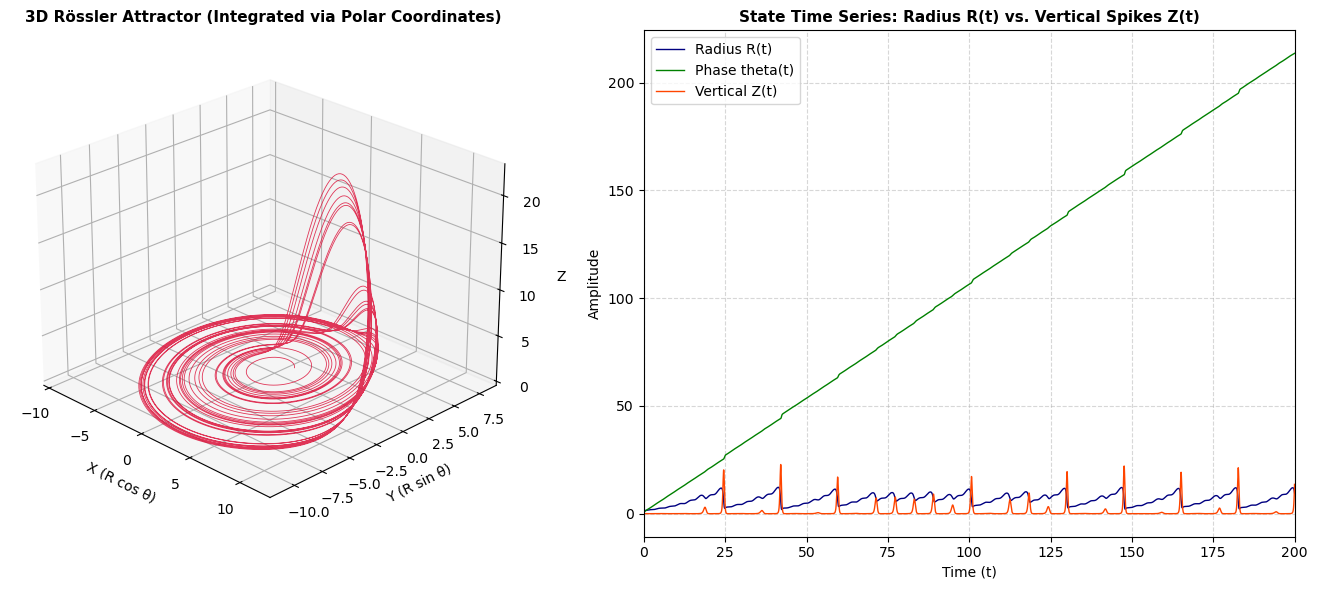

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Standard chaotic Rössler parameters
omega = 1.0
a = 0.2
b = 0.2
c = 5.7

# --- 1. Define 3D Polar Rössler ODE System ---

def rossler_polar(t, state, omega, a, b, c):
    R, theta, Z = state
    
    # Polar equations derived from dX/dt = -omega*Y - Z, dY/dt = omega*X + a*Y, dZ/dt = b + Z(X - c)
    dRdt = a * R * (np.sin(theta)**2) - Z * np.cos(theta)
    dthetadt = omega + (a / 2.0) * np.sin(2 * theta) + (Z / R) * np.sin(theta)
    dZdt = b + Z * (R * np.cos(theta) - c)
    
    return [dRdt, dthetadt, dZdt]

# --- 2. Initial Conditions & Integration Setup ---

# Initial conditions in Cartesian space
X0, Y0, Z0 = 1.0, 1.0, 0.1

# Convert initial conditions to Polar space
R0 = np.sqrt(X0**2 + Y0**2)
theta0 = np.arctan2(Y0, X0)

t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 20000)

# Solve system
sol = solve_ivp(
    rossler_polar,
    t_span,
    [R0, theta0, Z0],
    args=(omega, a, b, c),
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)

# Extract polar solutions
R_sol = sol.y[0]
theta_sol = sol.y[1]
Z_sol = sol.y[2]

# Map polar back to Cartesian for 3D trajectory visualization
X_sol = R_sol * np.cos(theta_sol)
Y_sol = R_sol * np.sin(theta_sol)

# --- 3. Visualization ---

fig = plt.figure(figsize=(14, 6))

# Subplot 1: 3D Reconstructed Phase Space (X, Y, Z)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(X_sol, Y_sol, Z_sol, color="crimson", lw=0.6, alpha=0.85)
ax1.set_title("3D Rössler Attractor (Integrated via Polar Coordinates)", fontsize=11, fontweight="bold")
ax1.set_xlabel("X (R cos θ)")
ax1.set_ylabel("Y (R sin θ)")
ax1.set_zlabel("Z")
ax1.view_init(elev=25, azim=-45)

# Subplot 2: Polar Variable Time Series
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(sol.t, R_sol, label="Radius R(t)", color="navy", lw=1)
ax2.plot(sol.t, theta_sol, label="Phase theta(t)", color="green", lw=1)
ax2.plot(sol.t, Z_sol, label="Vertical Z(t)", color="orangered", lw=1)
ax2.set_xlim(0, 200)  # Focus on steady-state chaotic behavior after initial transient
ax2.set_title("State Time Series: Radius R(t) vs. Vertical Spikes Z(t)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## The Angular Velocity

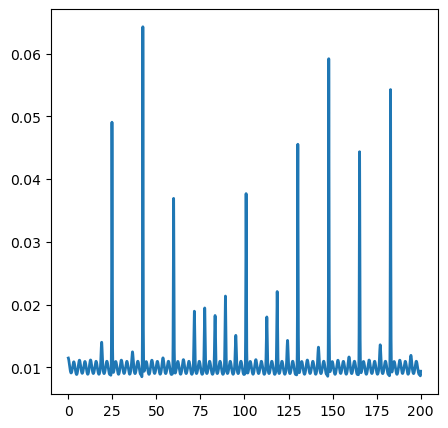

In [20]:
ang_velocity = np.gradient(theta_sol)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(sol.t, ang_velocity, label="X from Polar", color="tab:blue", linestyle="-", lw=2);
# ax.plot(theta_sol, label="Phase", color="blue", linestyle="-", lw=2);

ang_velocity.size

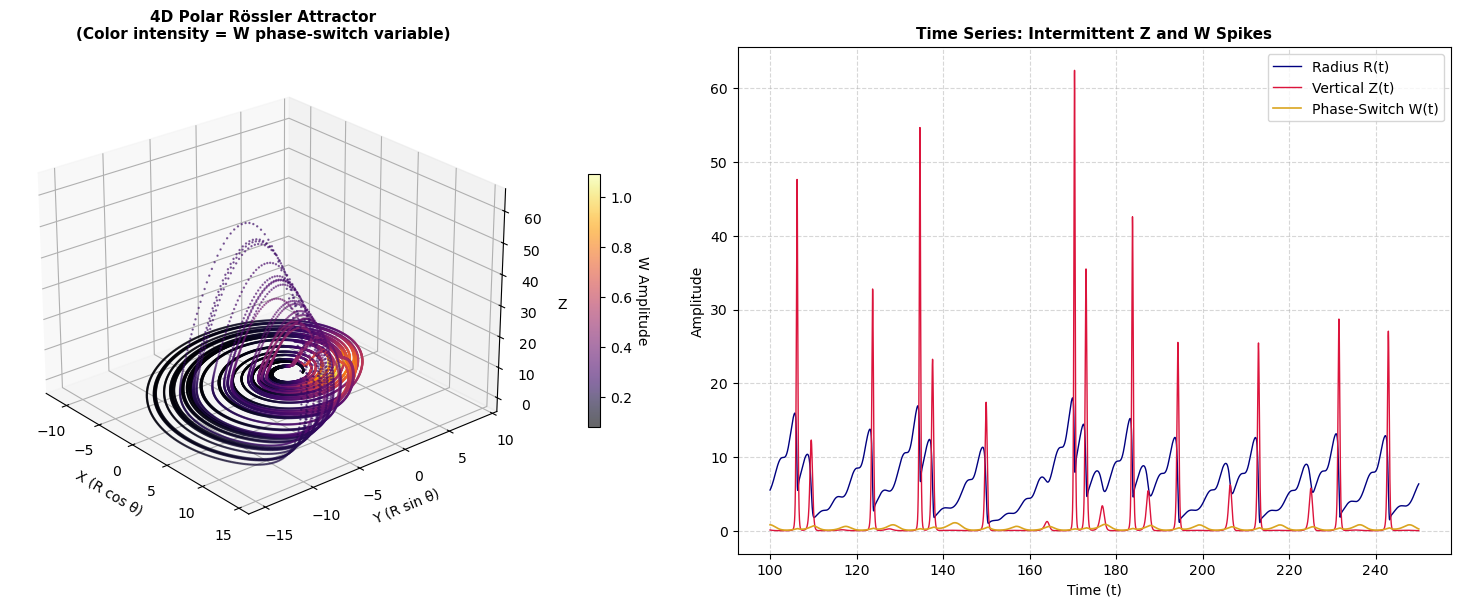

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. System Parameters ---
omega = 1.0     # Base oscillator frequency
a = 0.3        # Radial growth / shear parameter
b = 0.2         # Z-switch baseline
c = 5.7         # Z-switch threshold parameter

# 4th variable (W) parameters
d = 0.12         # W-switch baseline
e = 0.7         # Phase switch activation threshold (cos(theta) > e)
k_w = -0.6      # Phase feedback strength (torque kick from W onto dtheta/dt)

# --- 2. Define 4D Polar System ---

def rossler_4d_polar(t, state, omega, a, b, c, d, e, k_w):
    R, theta, Z, W = state
    
    # 1. Radial dynamics with Z-feedback
    dRdt = a * R * (np.sin(theta)**2) - Z * np.cos(theta)
    
    # 2. Angular velocity with Z-perturbation AND W phase-feedback kick
    dthetadt = omega + (a / 2.0) * np.sin(2 * theta) + (Z / R) * np.sin(theta) + k_w * W
    
    # 3. Primary non-linear switch (Z) activated by position X = R*cos(theta)
    dZdt = b + Z * (R * np.cos(theta) - c)
    
    # 4. Secondary phase-switch (W) activated when phase enters sector cos(theta) > e
    dWdt = d + W * (np.cos(theta) - e)
    
    return [dRdt, dthetadt, dZdt, dWdt]

# --- 3. Initial Conditions & Solver Setup ---

X0, Y0, Z0, W0 = 1.0, 1.0, 0.1, 0.1
R0 = np.sqrt(X0**2 + Y0**2)
theta0 = np.arctan2(Y0, X0)

t_span = (0, 250)
t_eval = np.linspace(t_span[0], t_span[1], 25000)

sol = solve_ivp(
    rossler_4d_polar,
    t_span,
    [R0, theta0, Z0, W0],
    args=(omega, a, b, c, d, e, k_w),
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)

# Extract states
R_sol, theta_sol, Z_sol, W_sol = sol.y

# Convert primary variables back to Cartesian for spatial plotting
X_sol = R_sol * np.cos(theta_sol)
Y_sol = R_sol * np.sin(theta_sol)

# --- 4. Plotting ---

fig = plt.figure(figsize=(15, 6))

# Subplot 1: 3D Projection of 4D Attractor (X, Y, Z space, color-coded by W intensity)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
sc = ax1.scatter(X_sol, Y_sol, Z_sol, c=W_sol, cmap="inferno", s=0.5, alpha=0.6)
ax1.set_title("4D Polar Rössler Attractor\n(Color intensity = W phase-switch variable)", fontsize=11, fontweight="bold")
ax1.set_xlabel("X (R cos θ)")
ax1.set_ylabel("Y (R sin θ)")
ax1.set_zlabel("Z")
ax1.view_init(elev=25, azim=-40)
cbar = fig.colorbar(sc, ax=ax1, shrink=0.5, pad=0.1)
cbar.set_label("W Amplitude", rotation=270, labelpad=12)

# Subplot 2: Multi-Variable Time Series (Transient removed)
ax2 = fig.add_subplot(1, 2, 2)
t_mask = sol.t >= 100  # Show t = 100 to 250
ax2.plot(sol.t[t_mask], R_sol[t_mask], label="Radius R(t)", color="navy", lw=1)
ax2.plot(sol.t[t_mask], Z_sol[t_mask], label="Vertical Z(t)", color="crimson", lw=1)
ax2.plot(sol.t[t_mask], W_sol[t_mask], label="Phase-Switch W(t)", color="goldenrod", lw=1.2)

ax2.set_title("Time Series: Intermittent Z and W Spikes", fontsize=11, fontweight="bold")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

25000

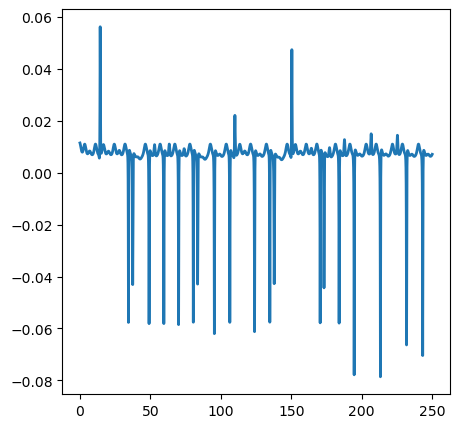

In [32]:
ang_velocity = np.gradient(theta_sol)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(sol.t, ang_velocity, label="X from Polar", color="tab:blue", linestyle="-", lw=2);
# ax.plot(theta_sol, label="Phase", color="blue", linestyle="-", lw=2);

ang_velocity.size

# The 4-Variable Equation

This is the 4-variable equation with feedback on the phase equation:

$$\begin{aligned} \frac{dR}{dt} &= a R \sin^2\theta - Z \cos\theta \\ \frac{d\theta}{dt} &= \omega + \frac{a}{2}\sin(2\theta) + \frac{Z}{R}\sin\theta + k_w W \\ \frac{dZ}{dt} &= b + Z(R \cos\theta - c) \\ \frac{dW}{dt} &= d + W(\cos\theta - e) \end{aligned}$$


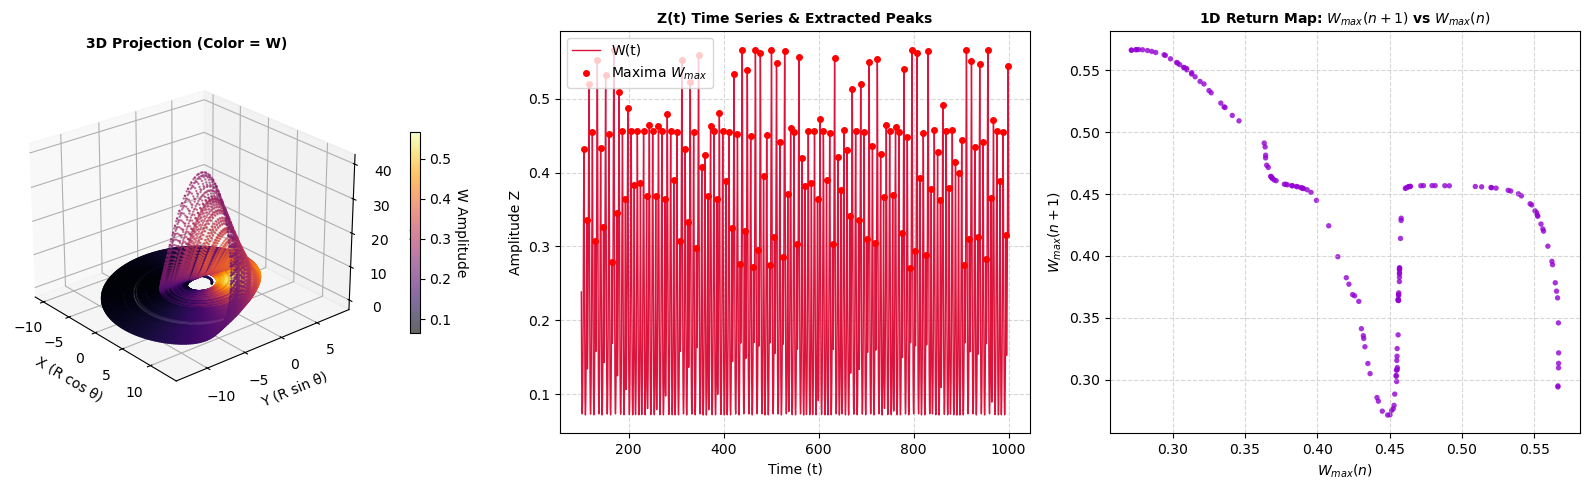

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# --- 1. System Parameters ---
omega = 1.0     # Base oscillator frequency
a = 0.25        # Radial growth / shear parameter
b = 0.2         # Z-switch baseline
c = 5.7         # Z-switch threshold parameter

# 4th variable (W) parameters
d = 0.1         # W-switch baseline
e = 0.7         # Phase switch activation threshold (cos(theta) > e)
k_w = -0.5      # Phase feedback strength onto dtheta/dt

# --- 2. Define 4D Polar System ---

def rossler_4d_polar(t, state, omega, a, b, c, d, e, k_w):
    R, theta, Z, W = state
    
    dRdt = a * R * (np.sin(theta)**2) - Z * np.cos(theta)
    dthetadt = omega + (a / 2.0) * np.sin(2 * theta) + (Z / R) * np.sin(theta) + k_w * W
    dZdt = b + Z * (R * np.cos(theta) - c)
    dWdt = d + W * (np.cos(theta) - e)
    
    return [dRdt, dthetadt, dZdt, dWdt]

# --- 3. Initial Conditions & Integration Setup ---

X0, Y0, Z0, W0 = 1.0, 1.0, 0.1, 0.1
R0 = np.sqrt(X0**2 + Y0**2)
theta0 = np.arctan2(Y0, X0)

t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 50000)

sol = solve_ivp(
    rossler_4d_polar,
    t_span,
    [R0, theta0, Z0, W0],
    args=(omega, a, b, c, d, e, k_w),
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)

# Extract states
R_sol, theta_sol, Z_sol, W_sol = sol.y
X_sol = R_sol * np.cos(theta_sol)
Y_sol = R_sol * np.sin(theta_sol)

# --- 4. Extract Peaks for Return Map (t in [100, 200]) ---

# Mask to isolate the second half of the time domain
mask_half = sol.t >= 100.0
t_second_half = sol.t[mask_half]
# Z_second_half = Z_sol[mask_half]
W_second_half = W_sol[mask_half]

# Find indices of local maxima in Z(t)
peak_indices, _ = find_peaks(W_second_half, height=0.1, distance=10)
W_max = W_second_half[peak_indices]

# Pair consecutive maxima: Z_max(n) vs Z_max(n+1)
# Z_n = Z_max[:-1]
# Z_n1 = Z_max[1:]

W_n = W_max[:-1]
W_n1 = W_max[1:]

# --- 5. Plotting ---

fig = plt.figure(figsize=(16, 5))

# Subplot 1: 3D Projection of Attractor
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
sc = ax1.scatter(X_sol, Y_sol, Z_sol, c=W_sol, cmap="inferno", s=0.5, alpha=0.6)
ax1.set_title("3D Projection (Color = W)", fontsize=10, fontweight="bold")
ax1.set_xlabel("X (R cos θ)")
ax1.set_ylabel("Y (R sin θ)")
ax1.set_zlabel("Z")
ax1.view_init(elev=25, azim=-40)
cbar = fig.colorbar(sc, ax=ax1, shrink=0.5, pad=0.1)
cbar.set_label("W Amplitude", rotation=270, labelpad=12)

# Subplot 2: Time Series with Extracted Peaks (t in [100, 200])
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(t_second_half, W_second_half, label="W(t)", color="crimson", lw=1)
ax2.plot(t_second_half[peak_indices], W_max, "ro", markersize=4, label="Maxima $W_{max}$")
ax2.set_title("Z(t) Time Series & Extracted Peaks", fontsize=10, fontweight="bold")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("Amplitude Z")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# Subplot 3: First-Return Map (Z_max(n+1) vs Z_max(n))
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(W_n, W_n1, color="darkviolet", s=15, alpha=0.8, edgecolors="none")
ax3.set_title("1D Return Map: $W_{max}(n+1)$ vs $W_{max}(n)$", fontsize=10, fontweight="bold")
ax3.set_xlabel("$W_{max}(n)$")
ax3.set_ylabel("$W_{max}(n+1)$")
ax3.grid(True, linestyle="--", alpha=0.5)

# Plot y = x diagonal reference line
# diag_min = min(np.min(W_n), np.min(W_n1))
# diag_max = max(np.max(W_n), np.max(W_n1))
# ax3.plot([diag_min, diag_max], [diag_min, diag_max], "k--", alpha=0.4, label="y = x")
# ax3.legend(loc="upper left")

plt.tight_layout()
plt.show()